<div style="float: left; font-size: 14pt;">BTE5476</div>
<div style="float: right; font-size: 13pt;"><a href="https://people.epfl.ch/paolo.prandoni">Paolo Prandoni</a>, <a href="https://www.bfh.ch/">BFH</a></div>
<div style="clear: both;"></div>

<h1 style="font-size: 30pt; color: #B51F1F;">Euler's formula without calculus</h1>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9,4.5)

# The most famous formula in mathematics

$$
    e^{jx} = \cos x + j \sin x
$$

(and, as a corollary, $e^{j\pi} + 1 = 0$)

# A brief history of number sets

 * we start from natural numbers: $\mathbb{N} = \{0, 1, 2, 3, \ldots\}$, where we have addition and multiplication with the standard rules
 * in $\mathbb{N}$ addition doesn't always have an inverse: $5-3=2$ is OK but $5-3 \not\in\mathbb{N}$ so we invent $\mathbb{Z}$ (signed integers)
 * in $\mathbb{Z}$ multiplication doesn't always have an inverse: $10/2=5$ is OK but $2/5 \not\in\mathbb{Z}$ so we invent $\mathbb{Q}$ (rationals)
 * in $\mathbb{Q}$ exponentiation doesn't always have an inverse: $\sqrt{4}=2$ is OK but $\sqrt{2} \not\in\mathbb{Q}$ so we invent $\mathbb{R}$ (real numbers)

# Numerical computation of fractional powers

Let's plot the graph $y = a^x$ for different values of the base $a$; for $x>1$ we get the classic exponential functions

In [2]:
def exponential(a, xmin, xmax, N=100):
    x = np.linspace(xmin, xmax, N)
    return x, np.power(a, x)

def plot_powers(xmin, xmax, bases):
    for a in bases:
        plt.plot(*exponential(a, xmin, xmax), label=f'$({a:.2f})^x$')
    plt.legend();
    plt.xlabel('$x$');    
    plt.ylabel('$a^x$');

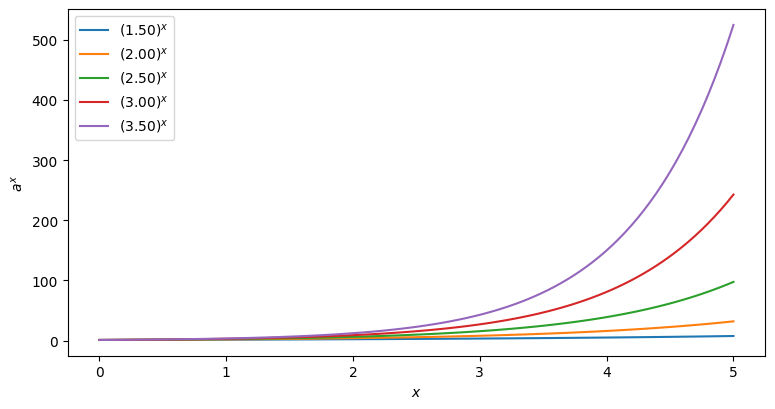

In [3]:
bases = [1.5, 2, 2.5, 3, 3.5]
plot_powers(0, 5, bases)

However, for $x$ small, the curves look like straight lines:

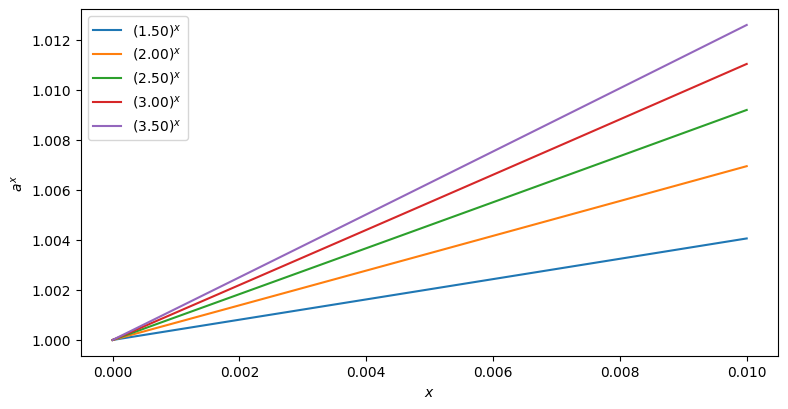

In [4]:
small_x = [0, 0.01]
plot_powers(*small_x, bases)

In fact, for $x$ small, the function $a^x$ can be approximated very well as
$$
    a^x \approx m_a x + c
$$

We can find the values of the parameter using linear fitting 

In [5]:
for a in bases:
    m, c = np.polyfit(*exponential(a, *small_x), 1)
    print(f'a = {a:.2f} -->  m={m:.4f}, c={c:.2f}')

a = 1.50 -->  m=0.4063, c=1.00
a = 2.00 -->  m=0.6956, c=1.00
a = 2.50 -->  m=0.9205, c=1.00
a = 3.00 -->  m=1.1047, c=1.00
a = 3.50 -->  m=1.2606, c=1.00


If we compare $a^x$ to $m_a x + 1$ we have an excellent fit

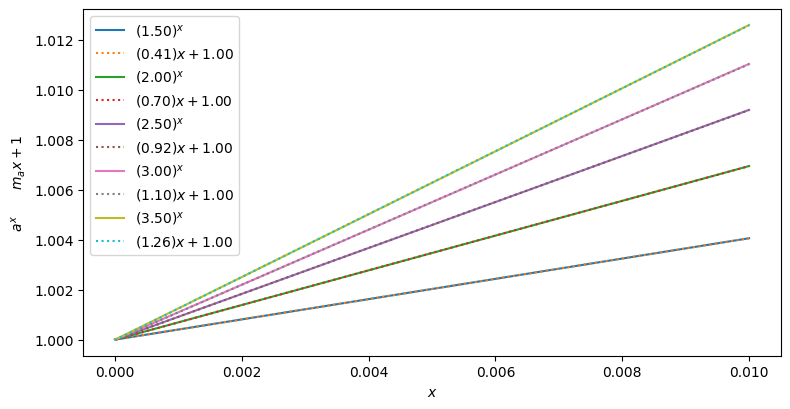

In [6]:
for a in bases:
    x, y = exponential(a, *small_x)
    m, c = np.polyfit(x, y, 1)
    plt.plot(x, y, label=f'$({a:.2f})^x$')
    plt.plot(x, m * x + c, ':', label=f'$({m:.2f})x + {c:.2f}$')
plt.legend();
plt.xlabel('$x$');    
plt.ylabel('$a^x \\qquad m_a x + 1$');

Let's look at the value of $m_a$, the slope of the straight lines, as a function of $a$; clearly there exist a value $2 < \hat{a} < 3$ for which $m_{\hat{a}} = 1$ so that the small-exponent approximation is simply $\hat{a}^x \approx 1 + x$.

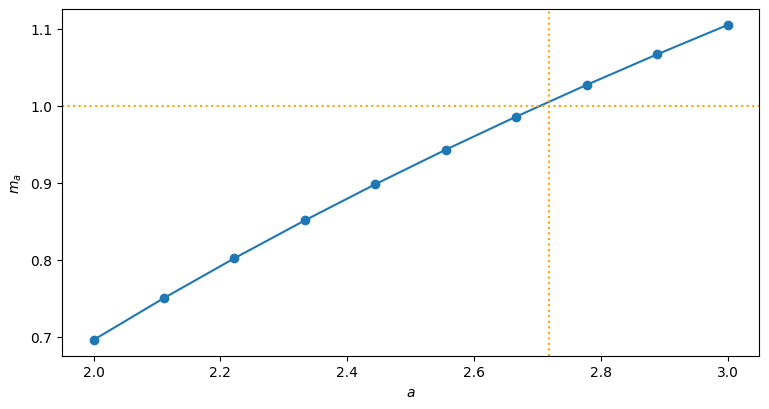

In [7]:
slope = []
base = np.linspace(2, 3, 10)
for a in base:
    x, y = exponential(a, *small_x)
    m, c = np.polyfit(x, y, 1)
    slope.append(m)
plt.plot(base, slope, 'o-');
plt.axhline(1, c='orange', ls=':');
plt.axvline(2.7183, c='orange', ls=':');
plt.xlabel('$a$');    
plt.ylabel('$m_a$');

Using $a^x \approx m_a x + 1$ for $x$ small we can find $\hat{a}$ via binary search:

* the search range is $[a_{\min}, a_{\max}]$
* we initialize $a_{\min} = 2$ and $a_{\max} = 3$
* at every step $n = 0, 1, 2, \ldots$:
    * $a_n = (a_{\min} + a_{\max}) / 2$ (center of the search range)
    * $m_n \approx (a_n^x - 1) / x$
    * if $m_n < 1$ then $a_{\min} \leftarrow a_n$ else $a_{\max} \leftarrow a_n$

We do this using simple square roots (instead of non-integer exponentiation) by picking $x = 2^{-R}$ for $R$ a large integer; for instance, if $R=3$,
$$
    m_n = \left(\sqrt{\sqrt{\sqrt{a_n}}} - 1\right) \cdot 2^3
$$

In [8]:
R = 20

search_range = [2.0, 3.0]
for n in range(15):
    a = b = np.mean(search_range)
    for r in range(R):
        b = np.sqrt(b)
    m = (b - 1) * (2 ** R)
    print(f'[{search_range[0]:.6f}, {search_range[1]:.6f}]  -->  {a}')
    if m > 1:
        search_range[1] = a
    else:
        search_range[0] = a

[2.000000, 3.000000]  -->  2.5
[2.500000, 3.000000]  -->  2.75
[2.500000, 2.750000]  -->  2.625
[2.625000, 2.750000]  -->  2.6875
[2.687500, 2.750000]  -->  2.71875
[2.687500, 2.718750]  -->  2.703125
[2.703125, 2.718750]  -->  2.7109375
[2.710938, 2.718750]  -->  2.71484375
[2.714844, 2.718750]  -->  2.716796875
[2.716797, 2.718750]  -->  2.7177734375
[2.717773, 2.718750]  -->  2.71826171875
[2.718262, 2.718750]  -->  2.718505859375
[2.718262, 2.718506]  -->  2.7183837890625
[2.718262, 2.718384]  -->  2.71832275390625
[2.718262, 2.718323]  -->  2.718292236328125


## Euler's constant

We just computed the value of $e$ (Euler's constant):
 * if powers and logarithms are in base $e$, we can easily compute a lot of decimals because the small-exponent approximation is easier
 * that's why $e$ is called the natural base for exponentiation (and logarithm)

to compute everything in base $e$:

 * $a^x = e^{\ln a^x} = e^{x\ln a}$; we can now see clearly that $m_a = \ln a$
 * if $\log_a b = x$ then $a^x = b$; so $\ln b = \ln a^x$ and therefore $x = \log_a b = (\ln b)/(\ln a)$

<br>
By now it should be clear that in the small-exponent approximation $a^x \approx m_a x + 1$, the slopes that we computed empirically are in fact 
$$
 m_a = \ln a
$$

# The final set of numbers, $\mathbb{C}$ 

 * even using real numbers, we can't solve problems such as $x^2 = -1$
 * this leads to the "invention" of imaginary numbers: $z = a + jb$ with $j^2 = -1$
 * keeping the imaginary unit separate, addition and multiplication still work according to the rules of distributivity and associativity

$$
    (a + jb)(c + jd) = ac - bd + j(ad + bc)
$$

Here is a simple implementation of complex multiplication:

In [9]:
def cmul(a: tuple, b: tuple) -> tuple:
    assert len(a) == len(b) == 2, 'operands shouldbe (real, imag) tuples'
    return (a[0] * b[0] - a[1] * b[1], a[0] * b[1] + a[1] * b[0])

In [10]:
# (1 + j)(1 - j) = 2
cmul((1, 1), (1, -1))

(2, 0)

Note how integer exponentiation of the imaginary unit resut in periodic sign alternations: $j^n = 1, j, -1, -j, 1, j, -1, -j, \ldots$

In [11]:
z = (0, 1)
for n in range(10):
    print(z, end=', ')
    z = cmul((0, 1), z)

(0, 1), (-1, 0), (0, -1), (1, 0), (0, 1), (-1, 0), (0, -1), (1, 0), (0, 1), (-1, 0), 

This is a crucial observation to understand the deep meaning of Euler's formula.

# Complex exponentiation

 * OK, now that we have imaginary numbers, we need to define the meaning of $a^z$ when $z$ is complex
 * let's assume that the standard exponentiation rules still work
 * if $z = y + jx$, $a^z = a^y\,a^{jx}$; the first term is a standard real-valued power, so let's focus on $a^{jx}$
   * since $a^{jx} = e^{j(\ln a) x}$, we will just study $e^{jx}$
   * again, we just need to consider $0 < x \le 1$, the rest follows

<br>

 * here's the trick: let's assume that the small-exponent approximation holds for imaginary numbers as well:
   $$
       e^{jx} \approx 1 + jx \quad \text{for $x$ small}
   $$

## computing complex exponentiation numerically

using the small-exponent approximation, let's compute iteratively $c_n = e^{jnx}$ for $x$ small:
 * $c_0 = e^0 = 1$
 * $c_1 = e^{jx} \approx 1 + jx$
 * $c_2 = e^{j2x} \approx (1 + jx)^2$
 * $\ldots$
 * $c_n =  e^{jnx} \approx c_{n-1}(1 + jx)$

we compute each step using the explicit complex multiplication algorithm shown earlier (no special functions)

In [12]:
c = (1, 0)
c1 = (1, 0.001)

N = 10000
real, imag = np.zeros(N), np.zeros(N)
for n in range(N):
    real[n], imag[n] = c
    c = cmul(c, c1)

And now let's plot the real and imaginary parts over a large range for $n$:

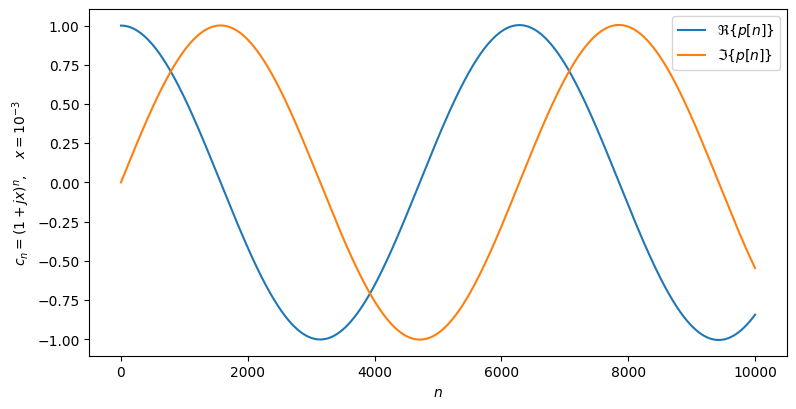

In [13]:
plt.plot(real, label='$\\Re\\{p[n]\\}$');
plt.plot(imag, label='$\\Im\\{p[n]\\}$');
plt.legend();
plt.xlabel('$n$');
plt.ylabel('$c_n = (1 + jx)^n, \\quad x=10^{-3}$');

when is $\Im\{e^{ja}) = 0$?

In [14]:
for n in range(len(imag) - 1):
    if imag[n] * imag[n+1] <= 0:
        print(f'Im{{p[n]}} = 0 for n/1000 = {n/1000}')
        print(f'Re{{p[{n}]}} = {real[n]}')
        break

Im{p[n]} = 0 for n/1000 = 0.0
Re{p[0]} = 1.0


and so, starting from first principles, we just found in a purely numerical way that:
 * $e^{jx} = \cos x + j \sin x$
 * $e^{j\pi} + 1 = 0$